
# Repairable Human Biology, proof-of-concept notebook

This notebook is a **synthetic, literature-informed proof of concept** for **Repairable Human Biology**.

## What it does
It creates a simulated molecular dataset representing transitions from more repairable to less repairable biological states across age and stress.  
The simulation is **benchmarked to directional patterns and representative ranges** reported in peer-reviewed journal literature, then uses those synthetic data to:

1. quantify age-associated shifts in repair-relevant molecular variables,
2. model a latent **repairability score**,
3. identify the strongest molecular correlates of repair failure,
4. classify **open vs closing repair windows**, and
5. test hypothetical intervention strategies in silico.

## Important note
These are **not real patient data**. They are **synthetic values** chosen to be biologically plausible and benchmarked to peer-reviewed PubMed-indexed studies and reviews.  
The notebook is intended as a **programme-design and analytical proof of concept**, not as a clinical or experimental claim.

## Literature anchors used to benchmark the simulation
The simulation is informed by the following PubMed-indexed sources:

1. López-Otín et al. *The hallmarks of aging*. Cell. 2013. https://www.cell.com/cell/fulltext/S0092-8674(13)00645-4
2. López-Otín et al. *Hallmarks of aging: An expanding universe*. Cell. 2023. https://www.cell.com/cell/fulltext/S0092-8674(22)01377-0
3. Mapuskar et al. *Mitochondrial superoxide increases age-associated susceptibility of human dermal fibroblasts to radiation and chemotherapy*. Aging Cell. 2017. https://doi.org/10.1158/0008-5472.CAN-17-0106
   - old fibroblasts reported ~2–4-fold higher steady-state superoxide, decreased ATP, and ~40–50% lower ETC complex activities.
4. Roger et al. *Mechanisms and Regulation of Cellular Senescence*. Int J Mol Sci. 2021. https://www.mdpi.com/1422-0067/22/23/13173
   - senescent fibroblasts accumulate γH2AX DNA damage foci and telomeres are often in the ~6–8 kbp range.
5. Nelson et al. *The senescent bystander effect is caused by ROS-activated NF-κB signalling*. Aging Cell. 2018. https://doi.org/10.1016/j.mad.2017.08.005
   - IL-6 and IL-8 are major components of the fibroblast SASP.
6. Stojanovic et al. *Oxidative Stress-Driven Cellular Senescence*. Oxid Med Cell Longev. 2025. https://doi.org/10.3390/antiox14080987
   - senescent cells show reduced oxidative phosphorylation, damaged mitochondria, and higher ROS.
7. Meller et al. *The aging proteostasis decline: From nematode to human*. Front Mol Biosci. 2021. PMC: https://pmc.ncbi.nlm.nih.gov/articles/PMC7868887/
   - aging and senescence are associated with proteostasis collapse.
8. Victorelli et al. *Apoptotic stress causes mtDNA release during senescence and drives the SASP*. Nat Cell Biol. 2023. https://www.nature.com/articles/s41586-023-06621-4
   - senescence-associated mtDNA release activates cGAS-STING-linked inflammatory programmes.

## Variables in the simulation
- Age and tissue context
- Mitochondrial superoxide / ROS
- ATP level
- ETC activity
- mtDNA copy number
- γH2AX foci
- IL-6
- p16 and p21
- Proteostasis capacity
- Autophagy / mitophagy flux
- Telomere length
- Cytosolic mtDNA burden
- A latent **repairability score**
- Binary state: **repair window open** vs **repair window closing/closed**


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

np.random.seed(42)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True


In [4]:

n = 2500

tissues = np.random.choice(
    ["fibroblast", "skeletal_muscle", "hepatocyte_like", "neuronal_like"],
    size=n,
    p=[0.35, 0.25, 0.20, 0.20]
)

age_group = np.random.choice(
    ["young", "midlife", "older", "aged_stressed"],
    size=n,
    p=[0.30, 0.28, 0.25, 0.17]
)

sex = np.random.choice(["female", "male"], size=n)

age_map = {
    "young": (22, 8),
    "midlife": (48, 7),
    "older": (67, 6),
    "aged_stressed": (79, 5),
}

age_years = np.array([np.random.normal(age_map[g][0], age_map[g][1]) for g in age_group])
age_years = np.clip(age_years, 18, 92)

tissue_mod = {
    "fibroblast":       {"ros": 1.00, "atp": 1.00, "etc": 1.00, "mtdna": 1.00, "il6": 1.05, "gamma": 1.00, "auto": 1.00, "prot": 1.00},
    "skeletal_muscle":  {"ros": 1.10, "atp": 1.08, "etc": 1.05, "mtdna": 1.12, "il6": 0.95, "gamma": 0.95, "auto": 0.98, "prot": 1.02},
    "hepatocyte_like":  {"ros": 1.08, "atp": 1.02, "etc": 1.00, "mtdna": 1.06, "il6": 1.10, "gamma": 1.05, "auto": 1.00, "prot": 1.03},
    "neuronal_like":    {"ros": 1.15, "atp": 0.96, "etc": 0.94, "mtdna": 1.08, "il6": 1.00, "gamma": 1.08, "auto": 0.95, "prot": 0.97},
}

group_anchor = {
    "young":         {"ros": 1.0, "atp": 100, "etc": 100, "mtdna": 100, "gamma": 4,  "il6": 1.0, "p16": 1.0, "p21": 1.1, "prot": 100, "auto": 100, "tel": 11.2, "cyto_mtDNA": 1.0},
    "midlife":       {"ros": 1.4, "atp": 92,  "etc": 90,  "mtdna": 92,  "gamma": 7,  "il6": 1.8, "p16": 1.7, "p21": 1.8, "prot": 90,  "auto": 88,  "tel": 9.6,  "cyto_mtDNA": 1.4},
    "older":         {"ros": 2.1, "atp": 78,  "etc": 68,  "mtdna": 82,  "gamma": 12, "il6": 3.3, "p16": 3.0, "p21": 2.8, "prot": 72,  "auto": 70,  "tel": 7.8,  "cyto_mtDNA": 2.2},
    "aged_stressed": {"ros": 3.0, "atp": 65,  "etc": 55,  "mtdna": 70,  "gamma": 18, "il6": 6.0, "p16": 5.0, "p21": 4.7, "prot": 58,  "auto": 55,  "tel": 6.7,  "cyto_mtDNA": 3.4},
}

rows = []
for i in range(n):
    g = age_group[i]
    t = tissues[i]
    a = age_years[i]
    mod = tissue_mod[t]
    anchor = group_anchor[g]

    ros = np.random.lognormal(mean=np.log(anchor["ros"] * mod["ros"]), sigma=0.18)
    atp = np.random.normal(anchor["atp"] * mod["atp"], 8)
    etc = np.random.normal(anchor["etc"] * mod["etc"], 8)
    mtdna = np.random.normal(anchor["mtdna"] * mod["mtdna"], 10)
    gamma = np.random.normal(anchor["gamma"] * mod["gamma"], 2.2)
    il6 = np.random.lognormal(mean=np.log(anchor["il6"] * mod["il6"]), sigma=0.28)
    p16 = np.random.lognormal(mean=np.log(anchor["p16"]), sigma=0.22)
    p21 = np.random.lognormal(mean=np.log(anchor["p21"]), sigma=0.22)
    proteostasis = np.random.normal(anchor["prot"] * mod["prot"], 8)
    autophagy = np.random.normal(anchor["auto"] * mod["auto"], 8)
    telomere = np.random.normal(anchor["tel"], 0.8)
    cytosolic_mtdna = np.random.lognormal(mean=np.log(anchor["cyto_mtDNA"]), sigma=0.25)

    atp -= 4.0 * (ros - 1.0)
    etc -= 4.5 * (ros - 1.0)
    gamma += 1.1 * max(0, ros - 1.0)
    il6 *= (1 + 0.10 * max(0, cytosolic_mtdna - 1.0))

    repairability = (
        0.028 * atp +
        0.025 * etc +
        0.020 * proteostasis +
        0.018 * autophagy +
        0.9 * telomere -
        8.0 * np.log1p(ros) -
        0.75 * gamma -
        1.8 * np.log1p(il6) -
        1.4 * np.log1p(p16) -
        1.0 * np.log1p(p21) -
        1.8 * np.log1p(cytosolic_mtdna) +
        np.random.normal(0, 1.2)
    )

    rows.append({
        "age_years": a,
        "age_group": g,
        "sex": sex[i],
        "tissue": t,
        "ros_fold_vs_young": ros,
        "atp_au": atp,
        "etc_activity_pct": etc,
        "mtdna_copy_index": mtdna,
        "gammaH2AX_foci": gamma,
        "IL6_pg_ml_index": il6,
        "p16_expr_fold": p16,
        "p21_expr_fold": p21,
        "proteostasis_pct": proteostasis,
        "autophagy_flux_pct": autophagy,
        "telomere_kbp": telomere,
        "cytosolic_mtDNA_fold": cytosolic_mtdna,
        "repairability_score": repairability,
    })

df = pd.DataFrame(rows)
for col in ["atp_au", "etc_activity_pct", "mtdna_copy_index", "proteostasis_pct", "autophagy_flux_pct"]:
    df[col] = df[col].clip(lower=10)
for col in ["gammaH2AX_foci", "telomere_kbp"]:
    df[col] = df[col].clip(lower=0.5)

threshold = df["repairability_score"].quantile(0.35)
df["repair_window_open"] = (df["repairability_score"] > threshold).astype(int)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (2500, 18)


,age_years,age_group,sex,tissue,ros_fold_vs_young,atp_au,etc_activity_pct,mtdna_copy_index,gammaH2AX_foci,IL6_pg_ml_index,p16_expr_fold,p21_expr_fold,proteostasis_pct,autophagy_flux_pct,telomere_kbp,cytosolic_mtDNA_fold,repairability_score,repair_window_open
0,59.256631,older,female,skeletal_muscle,2.395703,66.201581,65.437049,77.611231,13.950071,2.801470,2.716634,2.987056,67.259663,68.136288,6.588936,2.575841,-14.051741,0
1,66.140447,older,male,neuronal_like,3.992018,63.641273,56.761552,70.753743,19.557235,4.382664,2.697019,3.675904,67.804191,62.835799,8.180268,1.686438,-21.435814,0
2,55.675830,midlife,female,hepatocyte_like,1.250264,84.438504,81.596292,105.115000,6.268385,1.375030,1.487919,1.787356,83.252220,78.786551,11.289037,1.128998,0.851890,1
3,68.043731,aged_stressed,male,skeletal_muscle,3.088915,58.473487,53.320658,87.881430,18.724706,5.843412,6.618143,4.602444,73.002575,35.935313,6.856323,5.492739,-25.880928,0
4,34.275857,young,male,fibroblast,0.960224,102.523198,95.708626,96.879281,3.256807,0.880833,1.310421,1.217436,102.005026,106.468568,10.988515,0.824028,6.371615,1


In [6]:

display(df.describe(include="all").T)

group_summary = df.groupby("age_group")[[
    "ros_fold_vs_young","atp_au","etc_activity_pct","mtdna_copy_index","gammaH2AX_foci",
    "IL6_pg_ml_index","p16_expr_fold","p21_expr_fold","proteostasis_pct",
    "autophagy_flux_pct","telomere_kbp","cytosolic_mtDNA_fold","repairability_score",
    "repair_window_open"
]].mean().round(2)

print("Mean values by age group")
display(group_summary)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age_years,2500.0,NaN,NaN,NaN,50.210924,21.307502,18.0,29.667972,51.530003,68.461777,92.0
age_group,2500,4,young,771,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,2500,2,male,1268,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tissue,2500,4,fibroblast,878,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ros_fold_vs_young,2500.0,NaN,NaN,NaN,1.853631,0.848324,0.537596,1.178875,1.628861,2.359855,5.769
atp_au,2500.0,NaN,NaN,NaN,84.473764,18.116328,30.263541,71.530213,86.874683,98.54714,134.9246
etc_activity_pct,2500.0,NaN,NaN,NaN,77.773693,22.038578,18.684701,59.834437,82.474904,95.683893,122.723103
mtdna_copy_index,2500.0,NaN,NaN,NaN,93.71053,15.396508,39.666459,83.107326,94.193556,104.717718,141.381881
gammaH2AX_foci,2500.0,NaN,NaN,NaN,10.181197,6.227376,0.5,5.156705,8.860903,14.567127,27.203842
IL6_pg_ml_index,2500.0,NaN,NaN,NaN,3.201594,2.679368,0.386385,1.246891,2.225542,4.228977,17.254884


Mean values by age group


,ros_fold_vs_young,atp_au,etc_activity_pct,mtdna_copy_index,gammaH2AX_foci,IL6_pg_ml_index,p16_expr_fold,p21_expr_fold,proteostasis_pct,autophagy_flux_pct,telomere_kbp,cytosolic_mtDNA_fold,repairability_score,repair_window_open
age_group,,,,,,,,,,,,,,
aged_stressed,3.24,57.29,44.49,74.22,20.65,8.07,5.08,4.79,57.91,54.35,6.70,3.55,-26.84,0.00
midlife,1.52,91.68,87.84,97.76,7.59,2.02,1.75,1.87,90.66,86.82,9.56,1.44,-2.34,1.00
older,2.28,73.90,62.14,86.91,13.66,4.02,3.04,2.91,72.68,68.96,7.79,2.31,-14.59,0.26
young,1.07,100.96,99.11,105.87,4.17,1.06,1.03,1.13,100.60,98.50,11.17,1.02,6.02,1.00


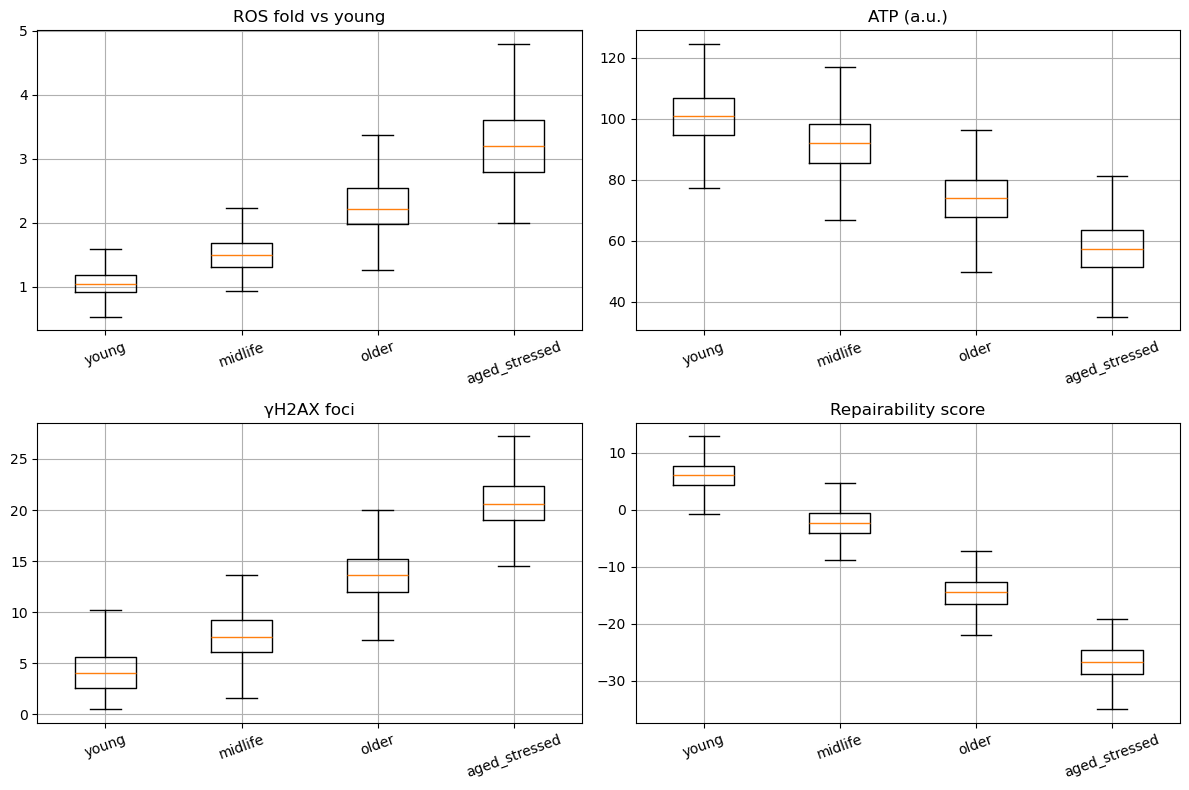

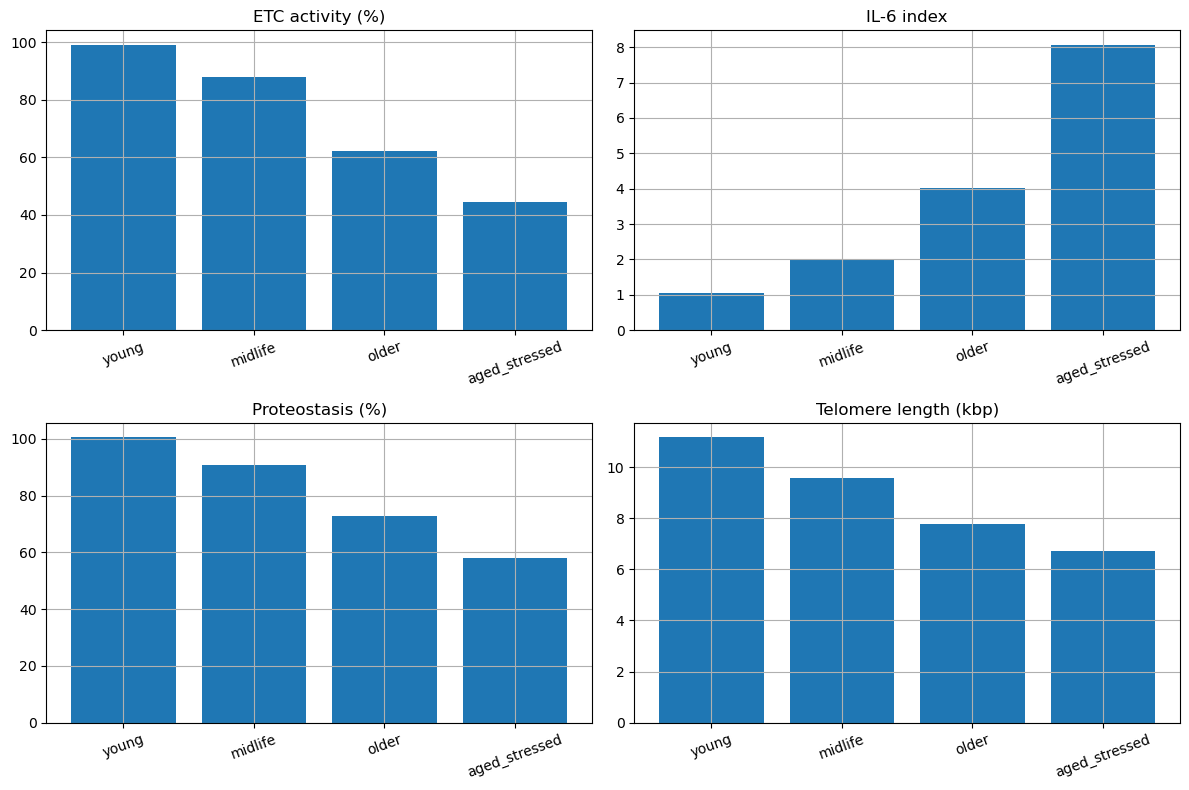

In [8]:

order = ["young", "midlife", "older", "aged_stressed"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_vars = [
    ("ros_fold_vs_young", "ROS fold vs young"),
    ("atp_au", "ATP (a.u.)"),
    ("gammaH2AX_foci", "γH2AX foci"),
    ("repairability_score", "Repairability score"),
]

for ax, (col, title) in zip(axes.ravel(), plot_vars):
    data = [df.loc[df["age_group"] == g, col].values for g in order]
    ax.boxplot(data, tick_labels=order, showfliers=False)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_vars = [
    ("etc_activity_pct", "ETC activity (%)"),
    ("IL6_pg_ml_index", "IL-6 index"),
    ("proteostasis_pct", "Proteostasis (%)"),
    ("telomere_kbp", "Telomere length (kbp)"),
]

for ax, (col, title) in zip(axes.ravel(), plot_vars):
    means = df.groupby("age_group")[col].mean().reindex(order)
    ax.bar(order, means.values)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


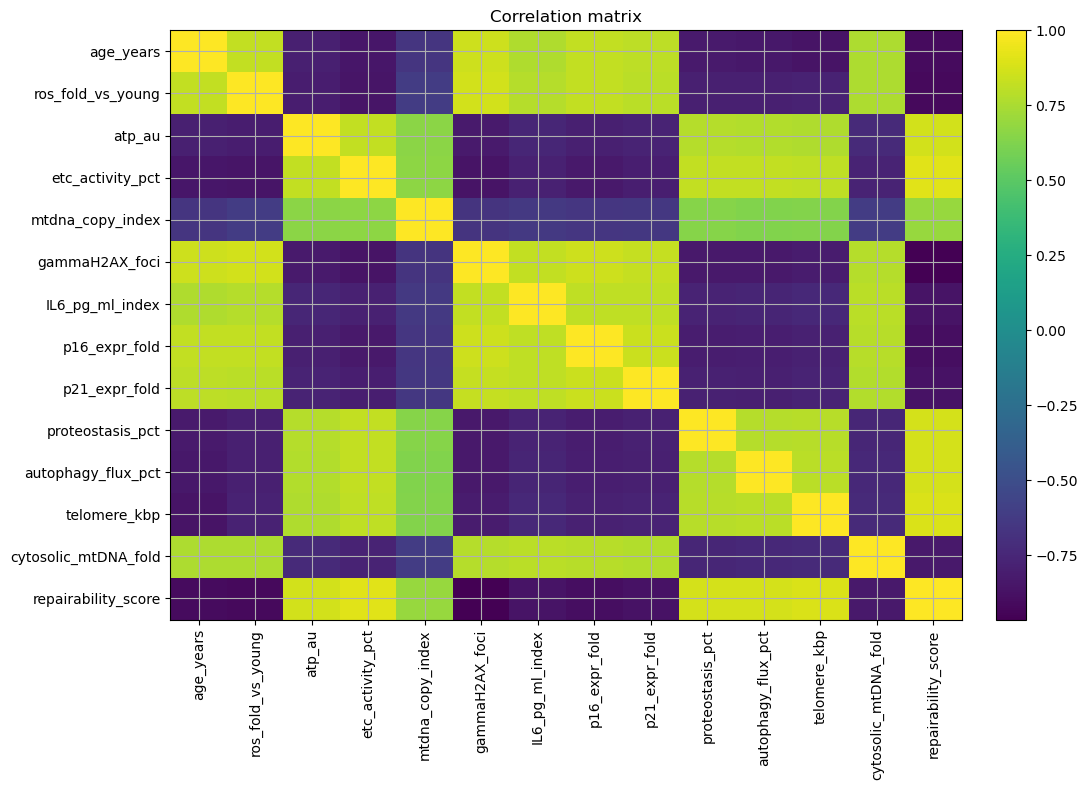

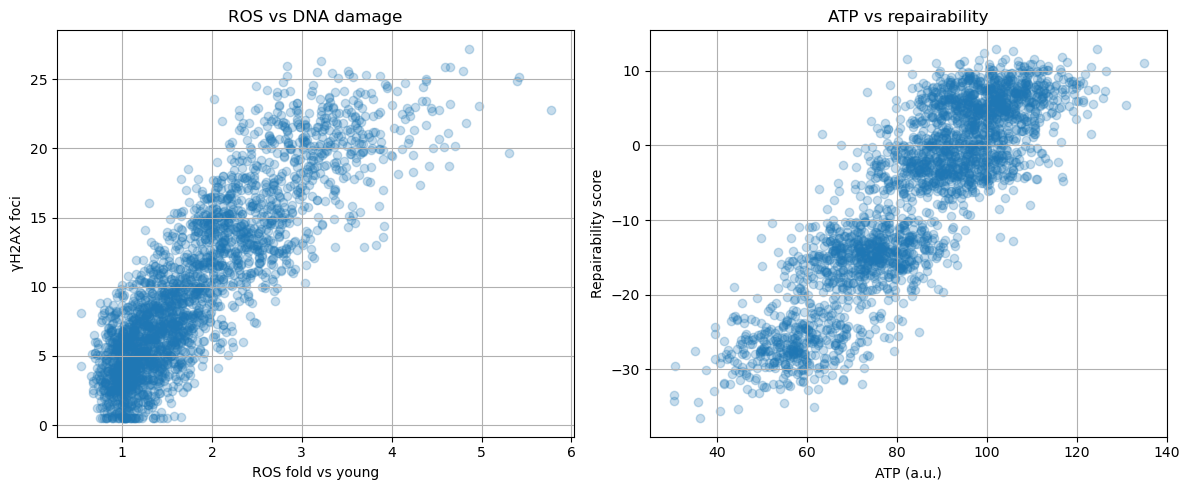

In [10]:

num_cols = [
    "age_years","ros_fold_vs_young","atp_au","etc_activity_pct","mtdna_copy_index",
    "gammaH2AX_foci","IL6_pg_ml_index","p16_expr_fold","p21_expr_fold","proteostasis_pct",
    "autophagy_flux_pct","telomere_kbp","cytosolic_mtDNA_fold","repairability_score"
]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(corr.values, aspect="auto")
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=90)
ax.set_yticklabels(num_cols)
ax.set_title("Correlation matrix")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(df["ros_fold_vs_young"], df["gammaH2AX_foci"], alpha=0.25)
axes[0].set_xlabel("ROS fold vs young")
axes[0].set_ylabel("γH2AX foci")
axes[0].set_title("ROS vs DNA damage")

axes[1].scatter(df["atp_au"], df["repairability_score"], alpha=0.25)
axes[1].set_xlabel("ATP (a.u.)")
axes[1].set_ylabel("Repairability score")
axes[1].set_title("ATP vs repairability")

plt.tight_layout()
plt.show()


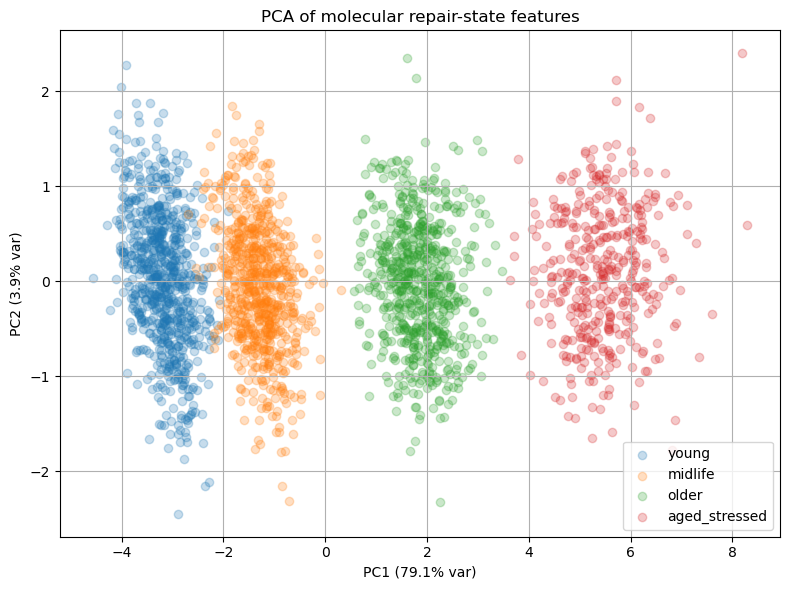

,ros_fold_vs_young,atp_au,gammaH2AX_foci,IL6_pg_ml_index,proteostasis_pct,autophagy_flux_pct,repairability_score,repair_window_open
state_cluster,,,,,,,,
0,1.52,91.52,7.57,2.00,90.58,86.82,-2.30,1.00
1,2.28,73.94,13.66,4.01,72.66,68.94,-14.59,0.26
2,3.24,57.24,20.64,8.09,57.96,54.38,-26.82,0.00
3,1.08,101.14,4.18,1.07,100.70,98.54,6.00,1.00


In [12]:

X_pca = df[[
    "ros_fold_vs_young","atp_au","etc_activity_pct","mtdna_copy_index","gammaH2AX_foci",
    "IL6_pg_ml_index","p16_expr_fold","p21_expr_fold","proteostasis_pct",
    "autophagy_flux_pct","telomere_kbp","cytosolic_mtDNA_fold"
]].copy()

X_scaled = (X_pca - X_pca.mean()) / X_pca.std()
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)

df["PC1"] = pcs[:, 0]
df["PC2"] = pcs[:, 1]

fig, ax = plt.subplots(figsize=(8, 6))
for g in order:
    m = df["age_group"] == g
    ax.scatter(df.loc[m, "PC1"], df.loc[m, "PC2"], alpha=0.25, label=g)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("PCA of molecular repair-state features")
ax.legend()
plt.tight_layout()
plt.show()

kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
df["state_cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = df.groupby("state_cluster")[[
    "ros_fold_vs_young","atp_au","gammaH2AX_foci","IL6_pg_ml_index",
    "proteostasis_pct","autophagy_flux_pct","repairability_score","repair_window_open"
]].mean().round(2)

display(cluster_summary)


Random forest classification performance
AUC: 0.997
Accuracy: 0.968
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       219
           1       0.98      0.97      0.98       406

    accuracy                           0.97       625
   macro avg       0.96      0.97      0.97       625
weighted avg       0.97      0.97      0.97       625



,feature_importance
gammaH2AX_foci,0.285491
ros_fold_vs_young,0.155254
p16_expr_fold,0.118619
etc_activity_pct,0.115487
age_years,0.100413
telomere_kbp,0.067514
IL6_pg_ml_index,0.063250
atp_au,0.029541
proteostasis_pct,0.023424
autophagy_flux_pct,0.018534


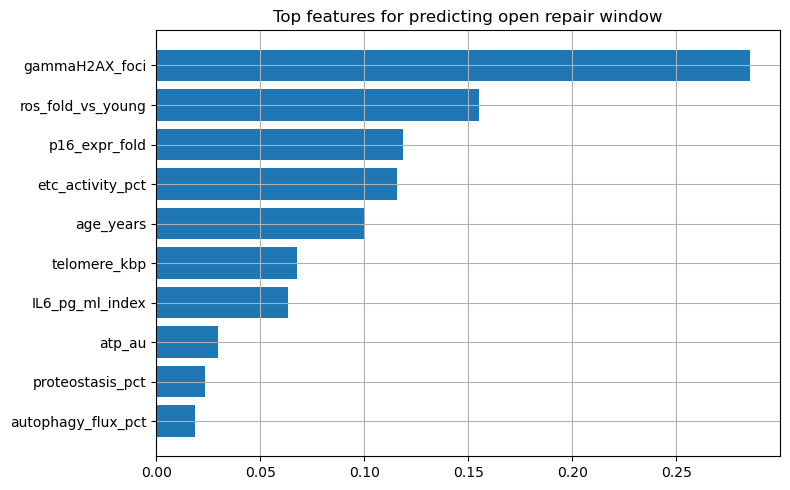

In [14]:

features = [
    "age_years","ros_fold_vs_young","atp_au","etc_activity_pct","mtdna_copy_index",
    "gammaH2AX_foci","IL6_pg_ml_index","p16_expr_fold","p21_expr_fold",
    "proteostasis_pct","autophagy_flux_pct","telomere_kbp","cytosolic_mtDNA_fold"
]
target = "repair_window_open"

X = df[features]
y = df[target]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=8,
    random_state=42
)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
proba = clf.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, proba)
acc = accuracy_score(y_test, pred)

print("Random forest classification performance")
print("AUC:", round(auc, 3))
print("Accuracy:", round(acc, 3))
print(classification_report(y_test, pred))

imp = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False)
display(imp.to_frame("feature_importance").head(12))

fig, ax = plt.subplots(figsize=(8, 5))
top = imp.head(10).sort_values()
ax.barh(top.index, top.values)
ax.set_title("Top features for predicting open repair window")
plt.tight_layout()
plt.show()


Random forest regression performance
R2: 0.984
RMSE: 1.528


,permutation_importance
gammaH2AX_foci,0.798581
age_years,0.030021
ros_fold_vs_young,0.021277
etc_activity_pct,0.013116
telomere_kbp,0.010655
IL6_pg_ml_index,0.005079
p16_expr_fold,0.004811
p21_expr_fold,0.000939
atp_au,0.000924
cytosolic_mtDNA_fold,0.000727


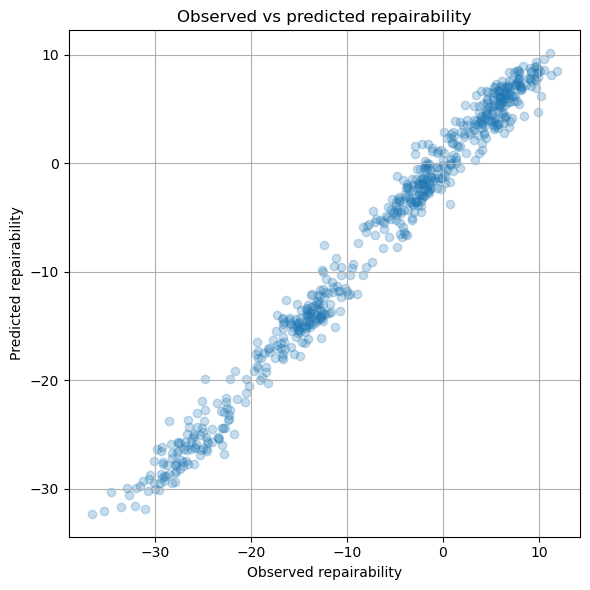

In [16]:

X = df[features]
y = df["repairability_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=6,
    random_state=42
)
reg.fit(X_train, y_train)
pred = reg.predict(X_test)

r2 = r2_score(y_test, pred)
rmse = mean_squared_error(y_test, pred) ** 0.5

print("Random forest regression performance")
print("R2:", round(r2, 3))
print("RMSE:", round(rmse, 3))

perm = permutation_importance(reg, X_test, y_test, n_repeats=6, random_state=42)
perm_imp = pd.Series(perm.importances_mean, index=features).sort_values(ascending=False)
display(perm_imp.to_frame("permutation_importance").head(12))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, pred, alpha=0.25)
ax.set_xlabel("Observed repairability")
ax.set_ylabel("Predicted repairability")
ax.set_title("Observed vs predicted repairability")
plt.tight_layout()
plt.show()


age_group,aged_stressed,midlife,older,young
scenario,,,,
anti_inflammatory,-25.90,-1.77,-14.22,6.07
baseline,-26.59,-2.32,-14.59,5.85
combined_reopen_repair,-17.42,2.17,-8.10,8.40
ddr_support,-21.26,-0.79,-11.82,6.85
mito_repair,-25.30,-0.97,-12.74,6.77
proteostasis_autophagy,-26.24,-1.76,-14.00,6.15


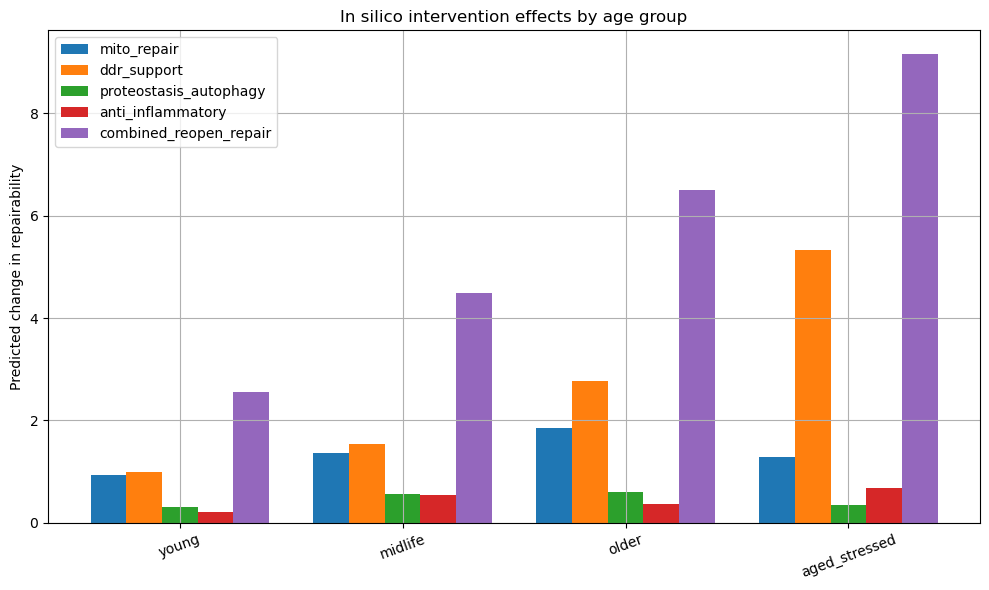

In [17]:

def apply_intervention(frame, mode):
    out = frame.copy()

    if mode == "mito_repair":
        out["ros_fold_vs_young"] *= 0.75
        out["atp_au"] *= 1.12
        out["etc_activity_pct"] *= 1.15
        out["mtdna_copy_index"] *= 1.08
        out["cytosolic_mtDNA_fold"] *= 0.75

    elif mode == "ddr_support":
        out["gammaH2AX_foci"] *= 0.78
        out["p21_expr_fold"] *= 0.90
        out["telomere_kbp"] *= 1.04

    elif mode == "proteostasis_autophagy":
        out["proteostasis_pct"] *= 1.18
        out["autophagy_flux_pct"] *= 1.20
        out["ros_fold_vs_young"] *= 0.92

    elif mode == "anti_inflammatory":
        out["IL6_pg_ml_index"] *= 0.60
        out["cytosolic_mtDNA_fold"] *= 0.88

    elif mode == "combined_reopen_repair":
        out["ros_fold_vs_young"] *= 0.68
        out["atp_au"] *= 1.15
        out["etc_activity_pct"] *= 1.18
        out["mtdna_copy_index"] *= 1.10
        out["gammaH2AX_foci"] *= 0.75
        out["IL6_pg_ml_index"] *= 0.55
        out["proteostasis_pct"] *= 1.18
        out["autophagy_flux_pct"] *= 1.22
        out["telomere_kbp"] *= 1.05
        out["cytosolic_mtDNA_fold"] *= 0.70
        out["p16_expr_fold"] *= 0.90
        out["p21_expr_fold"] *= 0.88

    return out

scenarios = [
    "mito_repair",
    "ddr_support",
    "proteostasis_autophagy",
    "anti_inflammatory",
    "combined_reopen_repair",
]

baseline_pred = reg.predict(df[features])
records = [pd.DataFrame({"age_group": df["age_group"], "scenario": "baseline", "pred_repairability": baseline_pred})]

for sc in scenarios:
    mod = apply_intervention(df, sc)
    pred = reg.predict(mod[features])
    records.append(pd.DataFrame({
        "age_group": df["age_group"],
        "scenario": sc,
        "pred_repairability": pred
    }))

sim = pd.concat(records, ignore_index=True)
sim_summary = sim.groupby(["scenario","age_group"])["pred_repairability"].mean().reset_index()
display(sim_summary.pivot(index="scenario", columns="age_group", values="pred_repairability").round(2))

baseline_means = sim_summary[sim_summary["scenario"] == "baseline"].set_index("age_group")["pred_repairability"]
effect = []
for sc in scenarios:
    tmp = sim_summary[sim_summary["scenario"] == sc].set_index("age_group")["pred_repairability"] - baseline_means
    for ag, val in tmp.items():
        effect.append({"scenario": sc, "age_group": ag, "delta_repairability": val})
effect = pd.DataFrame(effect)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(order))
width = 0.16

for i, sc in enumerate(scenarios):
    vals = effect[effect["scenario"] == sc].set_index("age_group").reindex(order)["delta_repairability"].values
    ax.bar(x + i*width, vals, width=width, label=sc)

ax.set_xticks(x + width*2)
ax.set_xticklabels(order, rotation=20)
ax.set_ylabel("Predicted change in repairability")
ax.set_title("In silico intervention effects by age group")
ax.legend()
plt.tight_layout()
plt.show()


In [20]:

interpretation = pd.DataFrame({
    "Finding": [
        "ROS rises across age/stress and tracks with DNA damage",
        "ATP and ETC decline as repairability falls",
        "IL-6 and cytosolic mtDNA rise in low-repair states",
        "Proteostasis and autophagy decline across transition states",
        "Combined intervention produces the largest simulated rescue"
    ],
    "Mechanistic interpretation": [
        "Oxidative burden may reinforce persistent DNA damage signalling and biological lock-in",
        "Energetic insufficiency may constrain successful execution of repair programmes",
        "mtDNA-linked inflammatory signalling may stabilize maladaptive senescent-like states",
        "Quality-control failure likely reduces resilience to repeated molecular insults",
        "Repairability appears multi-factorial, suggesting coordinated rescue should outperform single-node rescue"
    ]
})
display(interpretation)
print("Notebook complete.")


,Finding,Mechanistic interpretation
0,ROS rises across age/stress and tracks with DN...,Oxidative burden may reinforce persistent DNA ...
1,ATP and ETC decline as repairability falls,Energetic insufficiency may constrain successf...
2,IL-6 and cytosolic mtDNA rise in low-repair st...,mtDNA-linked inflammatory signalling may stabi...
3,Proteostasis and autophagy decline across tran...,Quality-control failure likely reduces resilie...
4,Combined intervention produces the largest sim...,"Repairability appears multi-factorial, suggest..."


Notebook complete.
